## Scope (relative to project)

The **lead research question for this repo** is the **propensity-score matching ATT** for **two years vs one-and-done** on **NBA seasons 1–5**, using **`college_1` only** as pre-treatment — see **`matching.ipynb`**.

This notebook (**`nba_did.ipynb`**) carries a **different design**: longitudinal reshape of NCAA + NBA seasons, indicators for **2 / 3 / 4 years** vs one-and-done in college, panel-style models, and optional **staggered difference-in-differences** tooling in CausalPy. Treat it as **exploratory / alternative causal framing**, not as the authoritative answer to the question above.

In [ ]:
import os

os.environ["PYTENSOR_FLAGS"] = "cxx="

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import causalpy as cp

# 1. Load Data
ncaa_nba = pd.read_csv("data/ncaa_nba_data.csv")

# 2. Reshape to Long Format
# Assuming columns are player_id, num_years_college, college_4...college_1, nba_season_1...nba_season_5
# We melt the dataset so each row is a player-time period
value_vars = [
    "college_4",
    "college_3",
    "college_2",
    "college_1",
    "nba_season_1",
    "nba_season_2",
    "nba_season_3",
    "nba_season_4",
    "nba_season_5",
]

long_df = ncaa_nba.melt(
    id_vars=["athlete_id", "num_years_college"],
    value_vars=value_vars,
    var_name="period",
    value_name="impact",
).dropna(subset=["impact"])

# 3. Create standardized 'time' variable (1 to 9) and Treatment indicators
time_map = {k: i + 1 for i, k in enumerate(value_vars)}
long_df["time"] = long_df["period"].map(time_map)

# Group indicators for OLS
for g in [2, 3, 4]:
    long_df[f"g{g}"] = (long_df["num_years_college"] == g).astype(int)

# Create a binary treatment indicator for CausalPy (1 if the player is in the NBA, 0 if in college)
long_df["treated"] = (long_df["time"] >= 5).astype(int)

/Users/brucechen/miniforge3/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [32]:
long_df.sample(5)

,athlete_id,num_years_college,period,impact,time,g2,g3,g4,impact_dm
6732,4065697,1,nba_season_5,0.790,5,0,0,0,-3.723500
2847,36409,4,college_4,25.000,-1,0,0,1,17.411556
1427,57041,4,college_2,1.547,-3,0,0,1,-2.251444
6733,62615,4,nba_season_5,1.478,5,0,0,1,-4.525444
4805,4066425,1,nba_season_2,1.535,2,0,0,0,-2.518600


This code prepares a panel dataset of athletes’ performance before and after entering the NBA so it can be used in a difference‑in‑differences style analysis. It begins by importing the required Python libraries for data manipulation, statistical modeling, and visualization. The dataset `ncaa_nba_data.csv` is then loaded into a pandas DataFrame called `ncaa_nba`.

The original dataset is structured in wide format, where each player has separate columns for different seasons (e.g., `college_4`, `college_3`, …, `nba_season_5`). To analyze changes over time, the code reshapes the data into long format using `pandas.melt()`. In this new structure, each row represents a single player–time observation, with the column `period` indicating the season and `impact` containing the corresponding performance metric. Rows with missing impact values are removed to ensure the analysis only uses observed performance data.

Next, the code constructs a standardized time index. A dictionary maps each season label to a numeric time value from 1 to 9, allowing the timeline to be treated as an ordered sequence of periods relative to the NBA transition. The code also creates indicator variables (`g2`, `g3`, and `g4`) that identify players who spent two, three, or four years in college, respectively. These will later allow the regression to estimate differences in outcomes across groups with different college durations.

Finally, the code defines a treatment indicator that marks when a player enters the NBA. Periods corresponding to NBA seasons (time ≥ 5) are coded as treated, while college periods are coded as untreated. This binary variable allows the dataset to distinguish pre‑NBA and post‑NBA observations, enabling causal analysis of how outcomes change once players transition from college to the NBA.

#### OLS

In [23]:
formula = "impact ~ C(time) + g2:C(time) + g3:C(time) + g4:C(time) + C(athlete_id)"

ols_model = smf.ols(formula, data=long_df).fit(
    cov_type="cluster", cov_kwds={"groups": long_df["athlete_id"]}
)

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 impact   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                 1.902e-12
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               1.00
Time:                        18:01:43   Log-Likelihood:                -11375.
No. Observations:                5126   AIC:                         2.442e+04
Df Residuals:                    4292   BIC:                         2.987e+04
Df Model:                         833                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

/Users/brucechen/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 841, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Users/brucechen/miniforge3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


This code estimates a panel regression to analyze how player performance evolves over time and how those patterns differ by years spent in college. The model uses `impact` as the outcome variable and includes categorical time fixed effects (`C(time)`) to control for period‑specific changes that affect all players. It also includes player fixed effects (`C(athlete_id)`), which account for time‑invariant differences in ability across athletes.

The model interacts time with indicators for players who spent two, three, or four years in college (`g2`, `g3`, `g4`). These interaction terms allow the regression to estimate how performance trajectories differ for these groups relative to the baseline group of one‑year college players. This structure effectively produces an event‑study style set of coefficients describing how outcomes evolve across the nine periods surrounding the transition from college to the NBA.

The regression is estimated using ordinary least squares, with standard errors clustered at the athlete level. Clustering accounts for the fact that multiple observations belong to the same player over time, allowing for correlation in errors within individuals and producing more reliable statistical inference.

In [24]:
coefs = []

for name in ols_model.params.index:
    if name.startswith("g") and ":C(time)" in name:
        g = int(name[1])  # group number
        t = int(name.split("[")[1].split("]")[0])

        coefs.append(
            {
                "group": g,
                "time": t,
                "coef": ols_model.params[name],
                "ci_low": ols_model.conf_int().loc[name, 0],
                "ci_high": ols_model.conf_int().loc[name, 1],
            }
        )

coef_df = pd.DataFrame(coefs)
coef_df.columns

Index(['group', 'time', 'coef', 'ci_low', 'ci_high'], dtype='object')

This code extracts the key interaction coefficients from the regression results for use in visualization or further analysis. Specifically, it focuses on the interaction terms between time and the college‑experience indicators (`g2`, `g3`, and `g4`), which represent how performance trajectories differ for players with additional years in college relative to one‑year players.

The loop iterates over each group (two‑, three‑, and four‑year college players) and each time period in the dataset. For each combination, it constructs the corresponding coefficient name used in the regression output (e.g., `g2:C(time)[T.5]`). If that term exists in the estimated model, the code retrieves the coefficient value along with the lower and upper bounds of its confidence interval.

Each set of results is stored as a dictionary containing the group, time period, estimated effect, and confidence interval. These dictionaries are collected in a list and then converted into a pandas DataFrame (`coef_df`), which provides a clean structure for plotting the event‑study coefficients across time and comparing trajectories across groups.

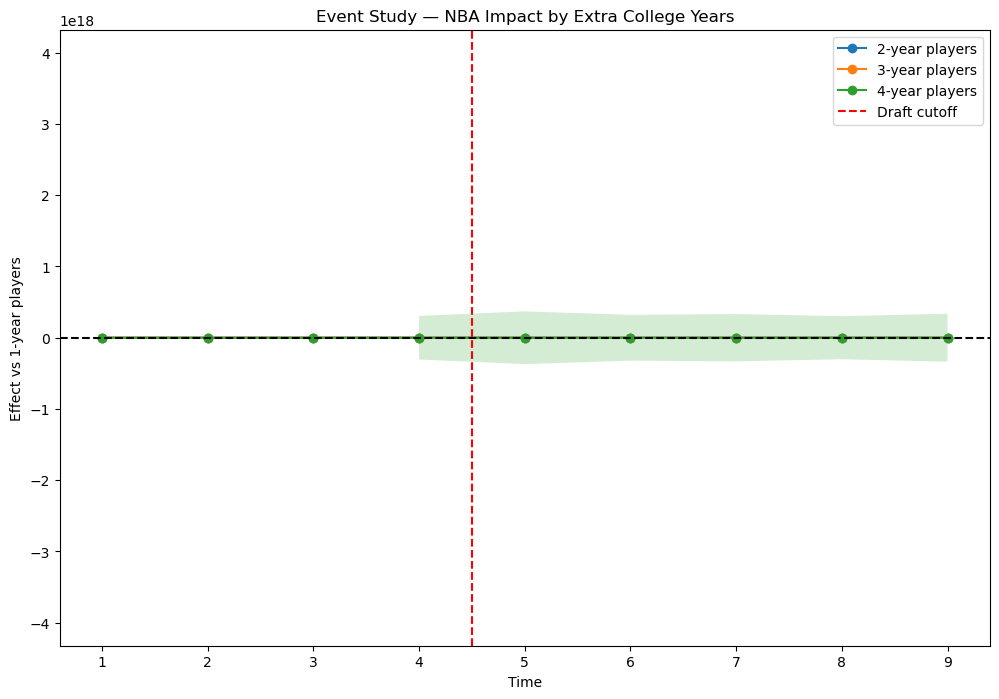

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))

for g in coef_df["group"].unique():
    gdf = coef_df[coef_df["group"] == g].sort_values("time")

    ax.plot(gdf["time"], gdf["coef"], marker="o", label=f"{g}-year players")
    ax.fill_between(gdf["time"], gdf["ci_low"], gdf["ci_high"], alpha=0.2)

ax.axhline(0, linestyle="--", color="black")
ax.axvline(4.5, linestyle="--", color="red", label="Draft cutoff")

ax.set_title("Event Study — NBA Impact by Extra College Years")
ax.set_xlabel("Time")
ax.set_ylabel("Effect vs 1‑year players")
ax.legend()

plt.show()

## 2

In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ── 1. Load data ──────────────────────────────────────────────────────────
DATA_PATH = "/Users/brucechen/Documents/IDS701 UDS/SP26_IDS701_UDS_Project/data/ncaa_nba_data.csv"
ncaa_nba = pd.read_csv(DATA_PATH)

# ── Treatment groups (DiD): control = 1 yr college; treatments = 2, 3, 4 yrs ──
_treat_map = {
    1: "control (1yr)",
    2: "treat_2yr",
    3: "treat_3yr",
    4: "treat_4yr",
}
ncaa_nba = ncaa_nba[ncaa_nba["num_years_college"].isin([1, 2, 3, 4])].copy()
ncaa_nba["treatment_group"] = ncaa_nba["num_years_college"].map(_treat_map)

score_cols = [
    "college_1",
    "college_2",
    "college_3",
    "college_4",
    "nba_season_1",
    "nba_season_2",
    "nba_season_3",
    "nba_season_4",
    "nba_season_5",
]
# Mean impact by group (each column is a season; NaNs ignored in groupby mean)
group_means = ncaa_nba.groupby("treatment_group", sort=False)[score_cols].mean()
print("Mean impact by treatment group (college_1 … nba_season_5):")
print(group_means.round(4).to_string(), "\n")

# ── 2. Reshape to long, centered on draft year ────────────────────────────
#
#   t = -4  freshman year     (college_1)
#   t = -3  sophomore year    (college_2)
#   t = -2  junior year       (college_3)
#   t = -1  senior year       (college_4)
#   t =  0  draft year        (no performance data → gap in plot)
#   t = +1  NBA season 1
#   ...
#   t = +5  NBA season 5
#
# A 1-year player only ever played at t=-1 before the draft.
# A 4-year player has data at t=-4,-3,-2,-1.
# Pre (post=0) = college seasons; post (post=1) = NBA seasons (after draft_year).

col_to_time = {
    "college_1": -4,
    "college_2": -3,
    "college_3": -2,
    "college_4": -1,
    "nba_season_1": 1,
    "nba_season_2": 2,
    "nba_season_3": 3,
    "nba_season_4": 4,
    "nba_season_5": 5,
}

long_df = ncaa_nba.melt(
    id_vars=["athlete_id", "num_years_college", "draft_year", "treatment_group"],
    value_vars=list(col_to_time.keys()),
    var_name="period",
    value_name="impact",
).dropna(subset=["impact"])

long_df["time"] = long_df["period"].map(col_to_time)
long_df["post"] = (long_df["time"] > 0).astype(int)  # 0 = pre-NBA (college), 1 = NBA

# Group treatment indicators (baseline = 1-year players)
for g in [2, 3, 4]:
    long_df[f"g{g}"] = (long_df["num_years_college"] == g).astype(int)

Mean impact by treatment group (college_1 … nba_season_5):
                 college_1  college_2  college_3  college_4  nba_season_1  nba_season_2  nba_season_3  nba_season_4  nba_season_5
treatment_group                                                                                                                  
treat_3yr           6.0557     8.8938    11.9490     5.2430        1.4358        1.9971        2.5475        3.0211        3.2097
control (1yr)       9.2969        NaN        NaN        NaN        2.1389        3.0453        3.9694        4.2450        4.5126
treat_4yr           6.1107     7.8528     9.8465    12.4258        1.1906        1.9558        2.1594        2.3089        2.5935
treat_2yr           7.2473    12.0537        NaN        NaN        1.7888        2.6683        3.4648        3.5019        3.9348 



In [9]:
ncaa_nba.sample(5)

,Player,College,draft_year,Pk,athlete_id,num_years_college,college_1,college_2,college_3,college_4,nba_season_1,nba_season_2,nba_season_3,nba_season_4,nba_season_5,treatment_group
377,Jeff Teague,Wake Forest,2009,19,36121,2,7.857,10.394,NaN,NaN,0.803,1.776,4.619,5.797,5.023,treat_2yr
813,Zach LaVine,UCLA,2014,13,66221,1,4.757,NaN,NaN,NaN,2.612,2.598,5.043,4.000,6.480,control (1yr)
5,Aaron Nesmith,Vanderbilt,2020,14,4396909,2,7.048,5.326,NaN,NaN,1.746,1.611,1.684,2.895,3.392,treat_2yr
788,VJ Edgecombe,Baylor,2025,3,5124612,1,12.597,NaN,NaN,NaN,4.864,NaN,NaN,NaN,NaN,control (1yr)
186,Delon Wright,Utah,2015,20,66236,2,17.033,19.258,NaN,NaN,1.511,2.226,3.461,4.692,3.177,treat_2yr


In [10]:
long_df.sample(5)

,athlete_id,num_years_college,draft_year,treatment_group,period,impact,time,post,g2,g3,g4
84,4397166,2,2020,treat_2yr,college_1,6.733,-4,0,1,0,0
537,26852,4,2010,treat_4yr,college_1,7.048,-4,0,0,0,1
1399,4066383,2,2018,treat_2yr,college_2,13.865,-3,0,1,0,0
635,45951,4,2013,treat_4yr,college_1,7.048,-4,0,0,0,1
3444,4066259,1,2017,control (1yr),nba_season_1,1.939,1,1,0,0,0


In [3]:
# ── 3. OLS with player + time FE, group-×-time interactions ──────────────
# Absorb player FE by demeaning (within-estimator) to avoid SVD non-convergence
# from the large dummy matrix. Time and interaction dummies are then small enough.

player_means = long_df.groupby("athlete_id")["impact"].transform("mean")
long_df["impact_dm"] = long_df["impact"] - player_means

formula = "impact_dm ~ C(time) + g2:C(time) + g3:C(time) + g4:C(time)"
ols_model = smf.ols(formula, data=long_df).fit(
    cov_type="cluster", cov_kwds={"groups": long_df["athlete_id"]}
)

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              impact_dm   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                -2.143e-13
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               1.00
Time:                        23:55:42   Log-Likelihood:                -11592.
No. Observations:                5126   AIC:                         2.325e+04
Df Residuals:                    5095   BIC:                         2.345e+04
Df Model:                          30                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.7054   2.54e+04      0.

/Users/brucechen/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Users/brucechen/miniforge3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


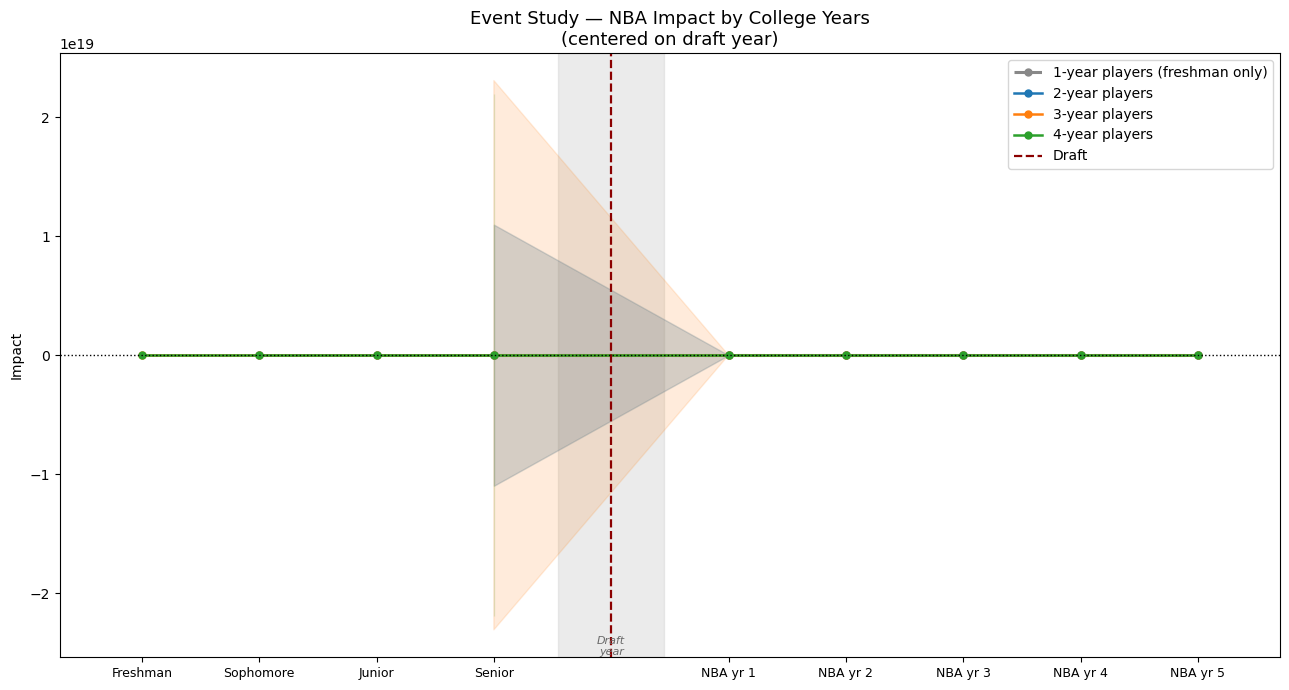

In [4]:
# ── 4. Extract coefficients ───────────────────────────────────────────────
all_times = [-4, -3, -2, -1, 1, 2, 3, 4, 5]
params = ols_model.params
ci = ols_model.conf_int()


def time_coef(t):
    """Main C(time) coefficient (1-year baseline). Reference level → 0."""
    key = f"C(time)[T.{t}]"
    if key in params:
        return params[key], ci.loc[key, 0], ci.loc[key, 1]
    return 0.0, 0.0, 0.0  # omitted reference period


def interaction_coef(g, t):
    """g{g}:C(time)[t] interaction. Returns NaN if absent (unobserved)."""
    key = f"g{g}:C(time)[{t}]"
    if key in params:
        return params[key], ci.loc[key, 0], ci.loc[key, 1]
    return np.nan, np.nan, np.nan


# ── 5. Build series: absolute trajectories for each group ─────────────────


def baseline_series():
    c, lo, hi = zip(*[time_coef(t) for t in all_times])
    return np.array(c), np.array(lo), np.array(hi)


def group_series(g):
    """Absolute trajectory = time FE + interaction."""
    c_arr, lo_arr, hi_arr = [], [], []
    for t in all_times:
        tc, tlo, thi = time_coef(t)
        ic, ilo, ihi = interaction_coef(g, t)
        c_arr.append(tc + ic)
        lo_arr.append(tlo + ilo)
        hi_arr.append(thi + ihi)
    return np.array(c_arr), np.array(lo_arr), np.array(hi_arr)


# ── 6. Mask time periods a group never observed ───────────────────────────
# 1-year players: only t=-1 in college (t=-4,-3,-2 are unobserved)
# 2-year players: t=-3,-2,-1 in college
# 3/4-year players: t=-4,-3,-2,-1 in college
# All groups observed at t=1..5 (NBA), subject to attrition / NaN above.

valid_college = {1: {-1}, 2: {-3, -2, -1}, 3: {-4, -3, -2, -1}, 4: {-4, -3, -2, -1}}
nba_times = {1, 2, 3, 4, 5}


def mask(arr, valid_times):
    out = arr.copy().astype(float)
    for i, t in enumerate(all_times):
        if t not in valid_times:
            out[i] = np.nan
    return out


b_c, b_lo, b_hi = baseline_series()
g2_c, g2_lo, g2_hi = group_series(2)
g3_c, g3_lo, g3_hi = group_series(3)
g4_c, g4_lo, g4_hi = group_series(4)

for g, arrs in [
    (1, [b_c, b_lo, b_hi]),
    (2, [g2_c, g2_lo, g2_hi]),
    (3, [g3_c, g3_lo, g3_hi]),
    (4, [g4_c, g4_lo, g4_hi]),
]:
    valid = valid_college[g] | nba_times
    for arr in arrs:
        for i, t in enumerate(all_times):
            if t not in valid:
                arr[i] = np.nan

# ── 7. Plot ────────────────────────────────────────────────────────────────
COLORS = {1: "#888888", 2: "#1f77b4", 3: "#ff7f0e", 4: "#2ca02c"}
LABELS = {
    1: "1-year players (freshman only)",
    2: "2-year players",
    3: "3-year players",
    4: "4-year players",
}

fig, ax = plt.subplots(figsize=(13, 7))

t_arr = np.array(all_times, dtype=float)

for g, c, lo, hi in [
    (1, b_c, b_lo, b_hi),
    (2, g2_c, g2_lo, g2_hi),
    (3, g3_c, g3_lo, g3_hi),
    (4, g4_c, g4_lo, g4_hi),
]:
    ax.plot(
        t_arr,
        c,
        marker="o",
        ms=5,
        label=LABELS[g],
        color=COLORS[g],
        linewidth=2.2 if g == 1 else 1.8,
        linestyle="--" if g == 1 else "-",
    )
    ax.fill_between(t_arr, lo, hi, alpha=0.15, color=COLORS[g])

# Draft line and zero reference
ax.axvline(0, linestyle="--", color="darkred", linewidth=1.6, label="Draft")
ax.axhline(0, linestyle=":", color="black", linewidth=1)

# Grey band for the t=0 gap (draft year, no game data)
ax.axvspan(-0.45, 0.45, color="lightgrey", alpha=0.45, zorder=0)
ax.text(
    0,
    ax.get_ylim()[0],
    "Draft\nyear",
    ha="center",
    va="bottom",
    fontsize=8,
    color="dimgrey",
    style="italic",
)

# Axis labels
ax.set_xticks(all_times)
ax.set_xticklabels(
    [
        "Freshman",
        "Sophomore",
        "Junior",
        "Senior",
        "NBA yr 1",
        "NBA yr 2",
        "NBA yr 3",
        "NBA yr 4",
        "NBA yr 5",
    ],
    fontsize=9,
)
ax.set_xlim(-4.7, 5.7)

ax.set_title(
    "Event Study — NBA Impact by College Years\n" "(centered on draft year)",
    fontsize=13,
)
ax.set_ylabel("Impact", fontsize=10)
ax.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("event_study_centered.png", dpi=150)
plt.show()

### 3